<a href="https://colab.research.google.com/github/Pushkarsinghs/indian_stock-analysis/blob/main/01_data_ingestion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Run this every day after market closes at 3:30 PM IST
# Schedule it using Google Colab + Google Cloud Scheduler (free tier)

from datetime import datetime
import pytz

IST = pytz.timezone("Asia/Kolkata")
now = datetime.now(IST)
print(f"🕒 Running at {now.strftime('%Y-%m-%d %H:%M:%S')} IST")

# Market is open Mon-Fri 9:15 AM to 3:30 PM IST
market_open  = now.replace(hour=9,  minute=15, second=0)
market_close = now.replace(hour=15, minute=30, second=0)

if now > market_close:
    print("✅ Market closed — fetching end of day data")
elif now < market_open:
    print("⏳ Market not open yet — fetching previous day data")
else:
    print("📈 Market is LIVE — data will be 15 min delayed")

🕒 Running at 2026-06-25 14:25:06 IST
📈 Market is LIVE — data will be 15 min delayed


In [ ]:
import yfinance as yf
import pandas as pd
import ta
import numpy as np

print("Fetching Reliance Industries data...")

ticker = yf.Ticker("RELIANCE.NS")
df = ticker.history(period="1mo")

# Technical Indicators
df["RSI"] = ta.momentum.RSIIndicator(df["Close"], window=14).rsi()
df["SMA_20"] = ta.trend.SMAIndicator(df["Close"], window=20).sma_indicator()
df["EMA_20"] = ta.trend.EMAIndicator(df["Close"], window=20).ema_indicator()

print("✅ Everything is working!")
print("\nLast 5 days of Reliance:")
print(df[["Close", "RSI", "SMA_20", "EMA_20"]].tail())

Fetching Reliance Industries data...
✅ Everything is working!

Last 5 days of Reliance:
                                 Close        RSI       SMA_20       EMA_20
Date                                                                       
2026-06-18 00:00:00+05:30  1328.099976  54.085428          NaN          NaN
2026-06-19 00:00:00+05:30  1309.500000  46.078149  1309.309302  1313.490687
2026-06-22 00:00:00+05:30  1326.500000  52.936368  1307.598871  1314.729669
2026-06-23 00:00:00+05:30  1309.500000  46.559085  1305.570972  1314.231605
2026-06-24 00:00:00+05:30  1313.599976  48.180492  1304.036743  1314.171450


In [ ]:
!pip install yfinance ta prophet pyportfolioopt nsepython textblob pyarrow -q


In [ ]:
import os

# Create project folder structure on your Google Drive
base = '/content/drive/MyDrive/indian_stock_analysis'
folders = ['data/raw', 'data/processed', 'data/output', 'scripts']

for folder in folders:
    os.makedirs(f'{base}/{folder}', exist_ok=True)

print("✅ Project folders created on Google Drive!")

✅ Project folders created on Google Drive!


# 📈 Indian Stock Market Analysis
## Notebook 1: Data Ingestion Pipeline

This notebook fetches live daily data for NIFTY 50 stocks from NSE using yfinance,
processes it and saves it to Google Drive in Parquet format for use in all other notebooks.

**Data Sources:** Yahoo Finance (yfinance) — NSE listed stocks
**Output:** Parquet files saved to Google Drive

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install required libraries
!pip install yfinance ta pyarrow nsepython -q

print("✅ Libraries ready!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Libraries ready!


In [ ]:
import os

BASE = '/content/drive/MyDrive/indian_stock_analysis'

folders = [
    'data/raw',
    'data/processed',
    'data/output',
    'scripts'
]

for folder in folders:
    os.makedirs(f'{BASE}/{folder}', exist_ok=True)

print("✅ Folder structure created!")
print("\nProject folders:")
for folder in folders:
    print(f"  📁 {BASE}/{folder}")

✅ Folder structure created!

Project folders:
  📁 /content/drive/MyDrive/indian_stock_analysis/data/raw
  📁 /content/drive/MyDrive/indian_stock_analysis/data/processed
  📁 /content/drive/MyDrive/indian_stock_analysis/data/output
  📁 /content/drive/MyDrive/indian_stock_analysis/scripts


In [ ]:
# Complete NIFTY 50 stock list (NSE tickers)
NIFTY_50 = [
    "RELIANCE.NS", "TCS.NS", "HDFCBANK.NS", "INFY.NS", "ICICIBANK.NS",
    "HINDUNILVR.NS", "ITC.NS", "SBIN.NS", "BHARTIARTL.NS", "KOTAKBANK.NS",
    "LT.NS", "AXISBANK.NS", "ASIANPAINT.NS", "MARUTI.NS", "SUNPHARMA.NS",
    "TITAN.NS", "ULTRACEMCO.NS", "BAJFINANCE.NS", "WIPRO.NS", "ONGC.NS",
    "NTPC.NS", "POWERGRID.NS", "TECHM.NS", "HCLTECH.NS", "JSWSTEEL.NS",
    "TATASTEEL.NS", "TATAMOTORS.NS", "NESTLEIND.NS", "DRREDDY.NS", "DIVISLAB.NS",
    "CIPLA.NS", "COALINDIA.NS", "BPCL.NS", "GRASIM.NS", "ADANIENT.NS",
    "ADANIPORTS.NS", "BAJAJFINSV.NS", "BAJAJ-AUTO.NS", "HEROMOTOCO.NS", "EICHERMOT.NS",
    "BRITANNIA.NS", "HINDALCO.NS", "UPL.NS", "SBILIFE.NS", "HDFCLIFE.NS",
    "APOLLOHOSP.NS", "TATACONSUM.NS", "INDUSINDBK.NS", "M&M.NS", "LTF.NS"
]

# Sector mapping for each stock
SECTOR_MAP = {
    "RELIANCE.NS": "Energy", "TCS.NS": "IT", "HDFCBANK.NS": "Banking",
    "INFY.NS": "IT", "ICICIBANK.NS": "Banking", "HINDUNILVR.NS": "FMCG",
    "ITC.NS": "FMCG", "SBIN.NS": "Banking", "BHARTIARTL.NS": "Telecom",
    "KOTAKBANK.NS": "Banking", "LT.NS": "Infrastructure", "AXISBANK.NS": "Banking",
    "ASIANPAINT.NS": "Paints", "MARUTI.NS": "Auto", "SUNPHARMA.NS": "Pharma",
    "TITAN.NS": "Consumer", "ULTRACEMCO.NS": "Cement", "BAJFINANCE.NS": "NBFC",
    "WIPRO.NS": "IT", "ONGC.NS": "Energy", "NTPC.NS": "Power",
    "POWERGRID.NS": "Power", "TECHM.NS": "IT", "HCLTECH.NS": "IT",
    "JSWSTEEL.NS": "Steel", "TATASTEEL.NS": "Steel", "TATAMOTORS.NS": "Auto",
    "NESTLEIND.NS": "FMCG", "DRREDDY.NS": "Pharma", "DIVISLAB.NS": "Pharma",
    "CIPLA.NS": "Pharma", "COALINDIA.NS": "Mining", "BPCL.NS": "Energy",
    "GRASIM.NS": "Cement", "ADANIENT.NS": "Conglomerate", "ADANIPORTS.NS": "Ports",
    "BAJAJFINSV.NS": "NBFC", "BAJAJ-AUTO.NS": "Auto", "HEROMOTOCO.NS": "Auto",
    "EICHERMOT.NS": "Auto", "BRITANNIA.NS": "FMCG", "HINDALCO.NS": "Metals",
    "UPL.NS": "Agrochemicals", "SBILIFE.NS": "Insurance", "HDFCLIFE.NS": "Insurance",
    "APOLLOHOSP.NS": "Healthcare", "TATACONSUM.NS": "FMCG",
    "INDUSINDBK.NS": "Banking", "M&M.NS": "Auto", "LTF.NS": "NBFC"
}

print(f"✅ Tracking {len(NIFTY_50)} NIFTY 50 stocks")
print(f"📊 Across {len(set(SECTOR_MAP.values()))} sectors")

✅ Tracking 50 NIFTY 50 stocks
📊 Across 21 sectors


In [ ]:
import yfinance as yf
import pandas as pd
from datetime import datetime

def fetch_stock_data(ticker, period="1y"):
    """Fetch historical data for a single stock"""
    try:
        stock = yf.Ticker(ticker)
        df = stock.history(period=period)

        if df.empty:
            print(f"  ⚠️  No data for {ticker}")
            return None

        df["Ticker"] = ticker
        df["Sector"] = SECTOR_MAP.get(ticker, "Unknown")
        df.reset_index(inplace=True)
        return df

    except Exception as e:
        print(f"  ❌ Error fetching {ticker}: {e}")
        return None

def fetch_all_nifty50(period="1y"):
    """Fetch data for all NIFTY 50 stocks"""
    all_data = []
    failed = []

    print(f"📥 Fetching {len(NIFTY_50)} stocks...\n")

    for i, ticker in enumerate(NIFTY_50, 1):
        df = fetch_stock_data(ticker, period)
        if df is not None:
            all_data.append(df)
            print(f"  ✅ [{i:02d}/{len(NIFTY_50)}] {ticker} — {len(df)} rows")
        else:
            failed.append(ticker)

    combined = pd.concat(all_data, ignore_index=True)

    print(f"\n📊 Total rows fetched: {len(combined):,}")
    print(f"📅 Date range: {combined['Date'].min().date()} → {combined['Date'].max().date()}")
    print(f"✅ Success: {len(all_data)} stocks")
    if failed:
        print(f"❌ Failed: {failed}")

    return combined

# Run the fetch
raw_df = fetch_all_nifty50(period="1y")

📥 Fetching 50 stocks...

  ✅ [01/50] RELIANCE.NS — 250 rows
  ✅ [02/50] TCS.NS — 250 rows
  ✅ [03/50] HDFCBANK.NS — 250 rows
  ✅ [04/50] INFY.NS — 250 rows
  ✅ [05/50] ICICIBANK.NS — 250 rows
  ✅ [06/50] HINDUNILVR.NS — 250 rows
  ✅ [07/50] ITC.NS — 250 rows
  ✅ [08/50] SBIN.NS — 250 rows
  ✅ [09/50] BHARTIARTL.NS — 250 rows
  ✅ [10/50] KOTAKBANK.NS — 250 rows
  ✅ [11/50] LT.NS — 250 rows
  ✅ [12/50] AXISBANK.NS — 250 rows
  ✅ [13/50] ASIANPAINT.NS — 250 rows
  ✅ [14/50] MARUTI.NS — 250 rows
  ✅ [15/50] SUNPHARMA.NS — 250 rows
  ✅ [16/50] TITAN.NS — 250 rows
  ✅ [17/50] ULTRACEMCO.NS — 250 rows
  ✅ [18/50] BAJFINANCE.NS — 250 rows
  ✅ [19/50] WIPRO.NS — 250 rows
  ✅ [20/50] ONGC.NS — 250 rows
  ✅ [21/50] NTPC.NS — 250 rows
  ✅ [22/50] POWERGRID.NS — 250 rows
  ✅ [23/50] TECHM.NS — 250 rows
  ✅ [24/50] HCLTECH.NS — 250 rows
  ✅ [25/50] JSWSTEEL.NS — 250 rows


ERROR:yfinance:$TATAMOTORS.NS: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")


  ✅ [26/50] TATASTEEL.NS — 250 rows
  ⚠️  No data for TATAMOTORS.NS
  ✅ [28/50] NESTLEIND.NS — 250 rows
  ✅ [29/50] DRREDDY.NS — 250 rows
  ✅ [30/50] DIVISLAB.NS — 249 rows
  ✅ [31/50] CIPLA.NS — 250 rows
  ✅ [32/50] COALINDIA.NS — 250 rows
  ✅ [33/50] BPCL.NS — 250 rows
  ✅ [34/50] GRASIM.NS — 250 rows
  ✅ [35/50] ADANIENT.NS — 250 rows
  ✅ [36/50] ADANIPORTS.NS — 250 rows
  ✅ [37/50] BAJAJFINSV.NS — 250 rows
  ✅ [38/50] BAJAJ-AUTO.NS — 250 rows
  ✅ [39/50] HEROMOTOCO.NS — 250 rows
  ✅ [40/50] EICHERMOT.NS — 250 rows
  ✅ [41/50] BRITANNIA.NS — 250 rows
  ✅ [42/50] HINDALCO.NS — 250 rows
  ✅ [43/50] UPL.NS — 250 rows
  ✅ [44/50] SBILIFE.NS — 250 rows
  ✅ [45/50] HDFCLIFE.NS — 250 rows
  ✅ [46/50] APOLLOHOSP.NS — 250 rows
  ✅ [47/50] TATACONSUM.NS — 250 rows
  ✅ [48/50] INDUSINDBK.NS — 250 rows
  ✅ [49/50] M&M.NS — 250 rows
  ✅ [50/50] LTF.NS — 250 rows

📊 Total rows fetched: 12,249
📅 Date range: 2025-06-24 → 2026-06-24
✅ Success: 49 stocks
❌ Failed: ['TATAMOTORS.NS']


In [ ]:
def clean_data(df):
    """Clean and standardize the raw data"""

    # Keep only needed columns
    df = df[["Date", "Ticker", "Sector", "Open", "High", "Low", "Close", "Volume"]].copy()

    # Remove timezone from Date
    df["Date"] = pd.to_datetime(df["Date"]).dt.tz_localize(None)

    # Remove duplicates
    df.drop_duplicates(subset=["Date", "Ticker"], inplace=True)

    # Remove rows with missing Close price
    df.dropna(subset=["Close"], inplace=True)

    # Round price columns to 2 decimal places
    for col in ["Open", "High", "Low", "Close"]:
        df[col] = df[col].round(2)

    # Sort by Ticker and Date
    df.sort_values(["Ticker", "Date"], inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Add useful columns
    df["Daily_Return"] = df.groupby("Ticker")["Close"].pct_change().round(4)
    df["Price_Change"] = (df["Close"] - df["Open"]).round(2)
    df["Price_Change_Pct"] = ((df["Price_Change"] / df["Open"]) * 100).round(2)

    print("✅ Data cleaned successfully!")
    print(f"\nShape: {df.shape}")
    print(f"\nColumns: {list(df.columns)}")
    print(f"\nSample data:")
    print(df.head(3))

    return df

clean_df = clean_data(raw_df)

✅ Data cleaned successfully!

Shape: (12249, 11)

Columns: ['Date', 'Ticker', 'Sector', 'Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 'Price_Change', 'Price_Change_Pct']

Sample data:
        Date       Ticker        Sector     Open     High      Low    Close  \
0 2025-06-24  ADANIENT.NS  Conglomerate  2502.88  2543.46  2499.08  2504.48   
1 2025-06-25  ADANIENT.NS  Conglomerate  2518.77  2540.46  2510.98  2526.07   
2 2025-06-26  ADANIENT.NS  Conglomerate  2533.87  2592.44  2521.07  2585.04   

    Volume  Daily_Return  Price_Change  Price_Change_Pct  
0   996372           NaN          1.60              0.06  
1   921346        0.0086          7.30              0.29  
2  1339627        0.0233         51.17              2.02  


In [ ]:
from datetime import datetime

def save_data(df):
    """Save data in multiple formats for Power BI and analysis"""

    today = datetime.today().strftime("%Y-%m-%d")

    # 1. Save as Parquet (for Python analysis - fast)
    parquet_path = f"{BASE}/data/processed/nifty50_master.parquet"
    df.to_parquet(parquet_path, index=False)
    print(f"✅ Parquet saved: {parquet_path}")

    # 2. Save daily snapshot as Parquet
    daily_path = f"{BASE}/data/raw/nifty50_{today}.parquet"
    df.to_parquet(daily_path, index=False)
    print(f"✅ Daily snapshot saved: {daily_path}")

    # 3. Save as CSV for Power BI
    csv_path = f"{BASE}/data/output/nifty50_for_powerbi.csv"
    df.to_csv(csv_path, index=False)
    print(f"✅ CSV for Power BI saved: {csv_path}")

    # 4. Save latest day only (for daily dashboard refresh)
    latest = df[df["Date"] == df["Date"].max()].copy()
    latest_path = f"{BASE}/data/output/nifty50_latest_day.csv"
    latest.to_csv(latest_path, index=False)
    print(f"✅ Latest day snapshot saved: {latest_path}")

    print(f"\n📁 All files saved to Google Drive!")
    print(f"📊 Total records saved: {len(df):,}")

save_data(clean_df)

✅ Parquet saved: /content/drive/MyDrive/indian_stock_analysis/data/processed/nifty50_master.parquet
✅ Daily snapshot saved: /content/drive/MyDrive/indian_stock_analysis/data/raw/nifty50_2026-06-24.parquet
✅ CSV for Power BI saved: /content/drive/MyDrive/indian_stock_analysis/data/output/nifty50_for_powerbi.csv
✅ Latest day snapshot saved: /content/drive/MyDrive/indian_stock_analysis/data/output/nifty50_latest_day.csv

📁 All files saved to Google Drive!
📊 Total records saved: 12,249


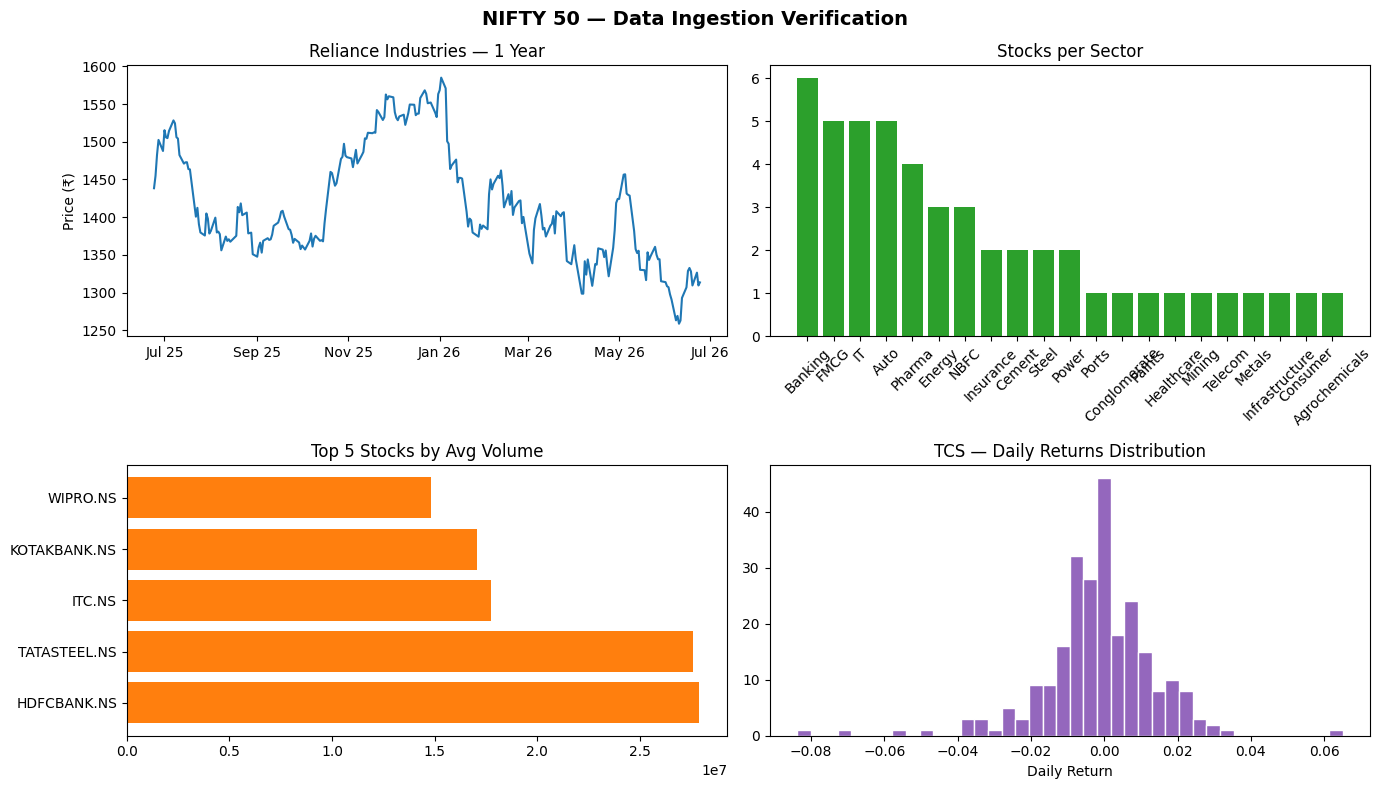

✅ Chart saved to Google Drive!


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('NIFTY 50 — Data Ingestion Verification', fontsize=14, fontweight='bold')

# Plot 1 — Reliance stock price
rel = clean_df[clean_df["Ticker"] == "RELIANCE.NS"]
axes[0,0].plot(rel["Date"], rel["Close"], color="#1f77b4", linewidth=1.5)
axes[0,0].set_title("Reliance Industries — 1 Year")
axes[0,0].set_ylabel("Price (₹)")
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))

# Plot 2 — Sector distribution
sector_counts = clean_df.drop_duplicates("Ticker")["Sector"].value_counts()
axes[0,1].bar(sector_counts.index, sector_counts.values, color="#2ca02c")
axes[0,1].set_title("Stocks per Sector")
axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3 — Top 5 stocks by volume
top_volume = clean_df.groupby("Ticker")["Volume"].mean().nlargest(5)
axes[1,0].barh(top_volume.index, top_volume.values, color="#ff7f0e")
axes[1,0].set_title("Top 5 Stocks by Avg Volume")

# Plot 4 — Daily returns distribution for TCS
tcs = clean_df[clean_df["Ticker"] == "TCS.NS"]["Daily_Return"].dropna()
axes[1,1].hist(tcs, bins=40, color="#9467bd", edgecolor="white")
axes[1,1].set_title("TCS — Daily Returns Distribution")
axes[1,1].set_xlabel("Daily Return")

plt.tight_layout()
plt.savefig(f"{BASE}/data/output/01_ingestion_verification.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to Google Drive!")

In [ ]:
# Mount Google Drive (to save your data files)
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
